# Experiment – 6 : Decision Tree Classification

---

**Name:** Shruti Hore  

**PRN:** 24070126172  

---

**Title:** Implementation of Decision Tree for Classification   

---

**Aim:** To implement and understand the Decision Tree algorithm for classification tasks and evaluate its performance on a given dataset.

---

**Objective:**

-	Understand the decision tree classification mechanism.

-	Implement the decision tree algorithm on a dataset for classification.

-	Evaluate the performance using relevant metrics such as accuracy, precision, recall, and F1-score.

-	Visualize the decision tree structure and its decision boundaries.

---

**Problem statement**

Use the given dataset(s) to demonstrate the application of the Decision Tree algorithm for classification. The task is to classify the data points into different classes based on the features and to understand how the decision tree algorithm splits the data at each node.

---

## Description
A Decision Tree is a non-parametric supervised learning algorithm used for classification and regression.

- Internal nodes → feature tests  
- Branches → outcomes  
- Leaf nodes → final prediction  

It creates a piecewise constant approximation of the target.

---

## Mathematical Formulation

### 1. Entropy
$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$

Range: $0 \leq Entropy \leq 1$

---

### 2. Information Gain
$$
IG(S, A) = Entropy(S) -
\sum_{v \in Values(A)}
\frac{|S_v|}{|S|}
Entropy(S_v)
$$

Choose attribute with maximum Information Gain.

---

### 3. Gini Index
$$
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

Lower Gini ⇒ Better split.

---

## Algorithm
1. Start with full dataset.
2. Compute impurity (Entropy/Gini).
3. Choose best feature (Max IG / Min Gini).
4. Split dataset.
5. Repeat until stopping condition.

# Data Preprocessing

In [30]:
import pandas as pd
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('(6) salaries.csv')
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [3]:
ip = df.drop('salary_more_then_100k', axis='columns') # x
tar = df['salary_more_then_100k'] # y

In [4]:
from sklearn.preprocessing import LabelEncoder
LE_com = LabelEncoder()
LE_job = LabelEncoder()
LE_degree = LabelEncoder()

In [5]:
ip['company_n'] = LE_com.fit_transform(ip['company'])
ip['job_n'] = LE_com.fit_transform(ip['job'])
ip['degree_n'] = LE_com.fit_transform(ip['degree'])
ip.head()

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0


In [6]:
ip_n = ip.drop(['company', 'job', 'degree'], axis='columns')
ip_n.head()

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0


# TREE

In [7]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [8]:
model.fit(ip_n, tar)

DecisionTreeClassifier()

In [9]:
model.score(ip_n, tar)

1.0

Is salary of google, computer engineer, bachlors degree > 100k?

In [10]:
model.predict([[2, 1, 0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

Is salary of google, computer engineer, maters degree > 100k?

In [11]:
model.predict([[2, 1, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [12]:
model.predict([[1, 2, 2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

# 2.

In [ ]:
data = pd.read_csv('(6) iphone_purchase_records.csv')
data.head(20)

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
5,Male,27,58000,0
6,Female,27,84000,0
7,Female,32,150000,1
8,Male,25,33000,0
9,Female,35,65000,0


In [14]:
data.shape

data.dtypes

,0
Gender,object
Age,int64
Salary,int64
Purchase Iphone,int64


In [15]:
# Feature Selection
X = data.iloc[: , :-1].values
y = data.iloc[: , 3].values

In [16]:
X

array([['Male', 19, 19000],
       ['Male', 35, 20000],
       ['Female', 26, 43000],
       ...,
       ['Female', 50, 20000],
       ['Male', 36, 33000],
       ['Female', 49, 36000]], dtype=object)

In [17]:
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [18]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

X[ : ,0] =LE.fit_transform(X[ : ,0])
X

array([[1, 19, 19000],
       [1, 35, 20000],
       [0, 26, 43000],
       ...,
       [0, 50, 20000],
       [1, 36, 33000],
       [0, 49, 36000]], dtype=object)

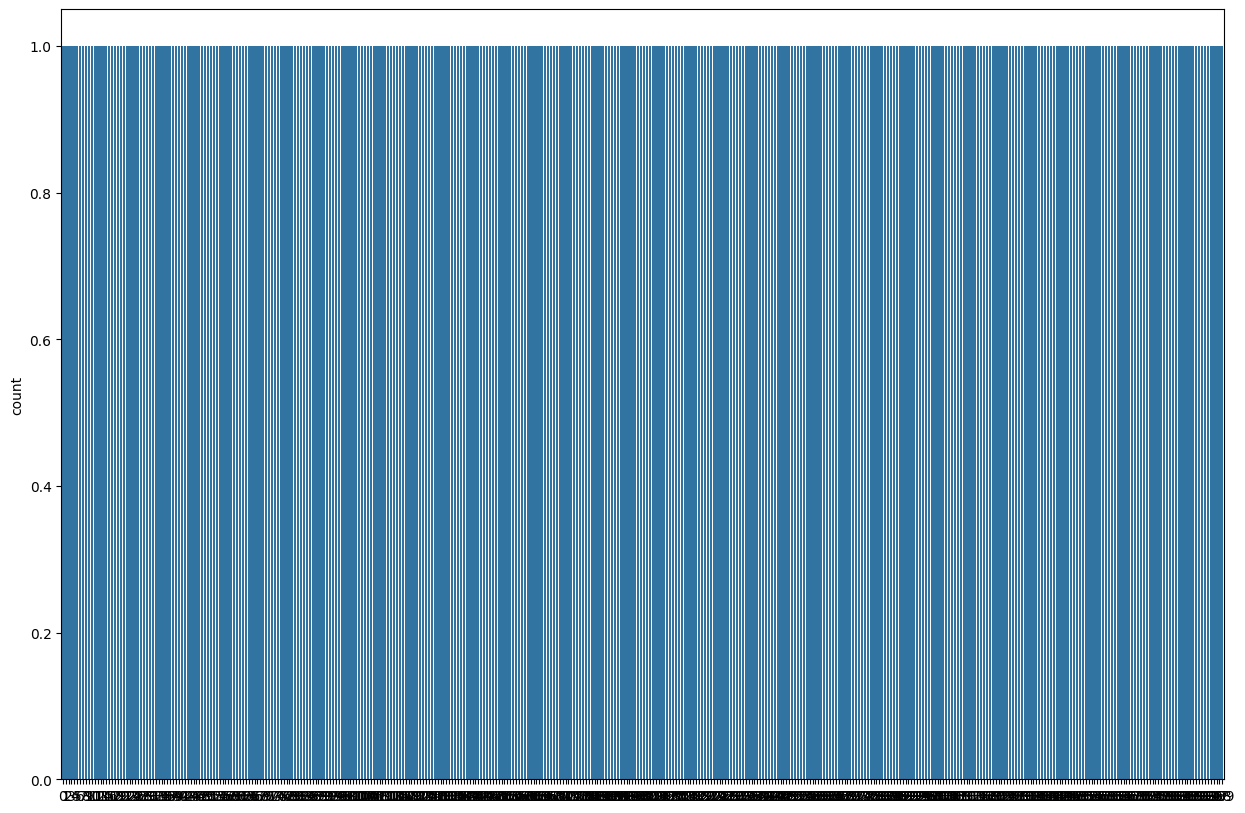

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.countplot(data['Age'])
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [21]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(criterion='gini')
DTC.fit(X_train, y_train)

DecisionTreeClassifier()

In [22]:
DTC.score(X_train, y_train)

1.0

In [23]:
y_pred = DTC.predict(X_test)

[Text(0.465625, 0.9583333333333334, 'x[1] <= 44.5\ngini = 0.466\nsamples = 300\nvalue = [189, 111]'),
 Text(0.23125, 0.875, 'x[2] <= 90500.0\ngini = 0.303\nsamples = 215\nvalue = [175, 40]'),
 Text(0.3484375, 0.9166666666666667, 'True  '),
 Text(0.1125, 0.7916666666666666, 'x[1] <= 36.5\ngini = 0.076\nsamples = 176\nvalue = [169, 7]'),
 Text(0.0875, 0.7083333333333334, 'gini = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.1375, 0.7083333333333334, 'x[2] <= 83500.0\ngini = 0.2\nsamples = 62\nvalue = [55, 7]'),
 Text(0.1125, 0.625, 'x[2] <= 67500.0\ngini = 0.153\nsamples = 60\nvalue = [55, 5]'),
 Text(0.0875, 0.5416666666666666, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.1375, 0.5416666666666666, 'x[2] <= 70500.0\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.1125, 0.4583333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.1625, 0.4583333333333333, 'x[2] <= 78500.0\ngini = 0.245\nsamples = 28\nvalue = [24, 4]'),
 Text(0.1375, 0.375, 'x[2] <= 72500.0\ngi

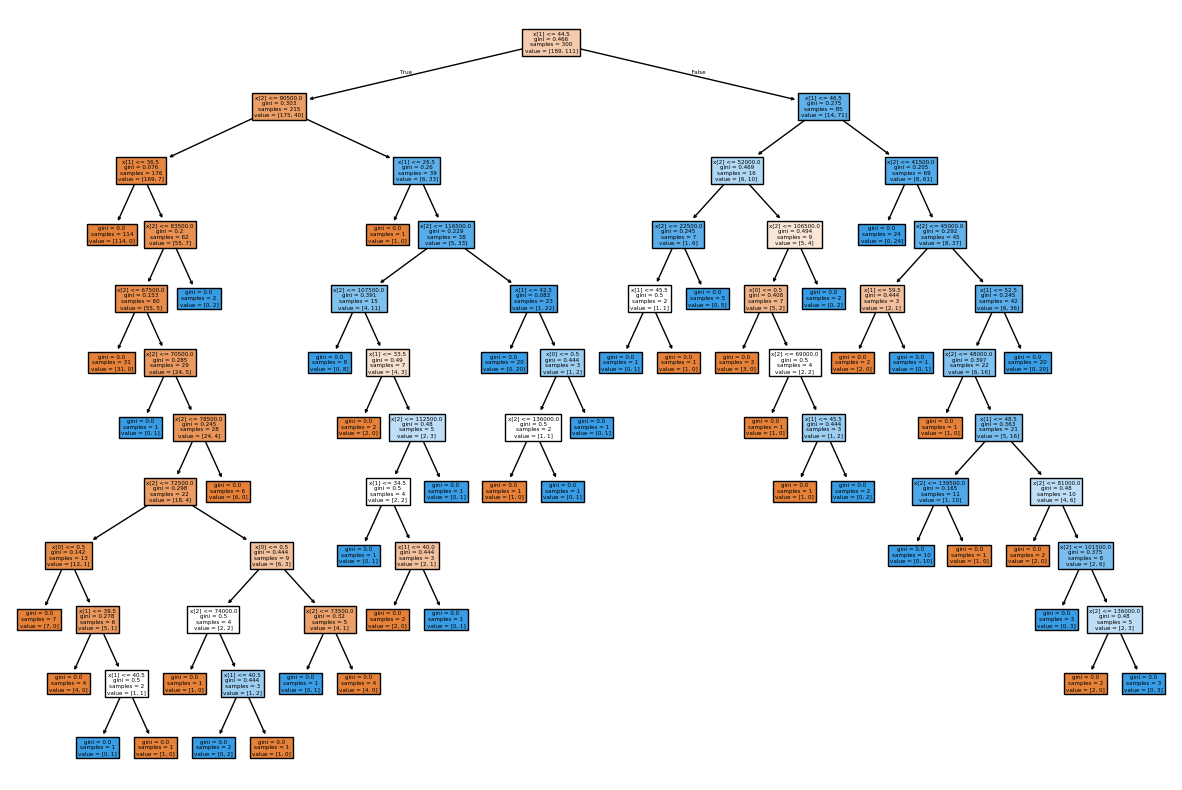

In [24]:
from sklearn import tree
plt.figure(figsize=(15, 10))
tree.plot_tree(DTC, filled=True)

[Text(0.4375, 0.9285714285714286, 'node #0\nx[1] <= 44.5\ngini = 0.466\nsamples = 300\nvalue = [189, 111]'),
 Text(0.16071428571428573, 0.7857142857142857, 'node #1\nx[2] <= 90500.0\ngini = 0.303\nsamples = 215\nvalue = [175, 40]'),
 Text(0.29910714285714285, 0.8571428571428572, 'True  '),
 Text(0.07142857142857142, 0.6428571428571429, 'node #2\nx[1] <= 36.5\ngini = 0.076\nsamples = 176\nvalue = [169, 7]'),
 Text(0.03571428571428571, 0.5, 'node #3\ngini = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.10714285714285714, 0.5, 'node #4\nx[2] <= 83500.0\ngini = 0.2\nsamples = 62\nvalue = [55, 7]'),
 Text(0.07142857142857142, 0.35714285714285715, 'node #5\nx[2] <= 67500.0\ngini = 0.153\nsamples = 60\nvalue = [55, 5]'),
 Text(0.03571428571428571, 0.21428571428571427, 'node #6\ngini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.10714285714285714, 0.21428571428571427, 'node #7\nx[2] <= 70500.0\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.07142857142857142, 0.07142857142857142, '

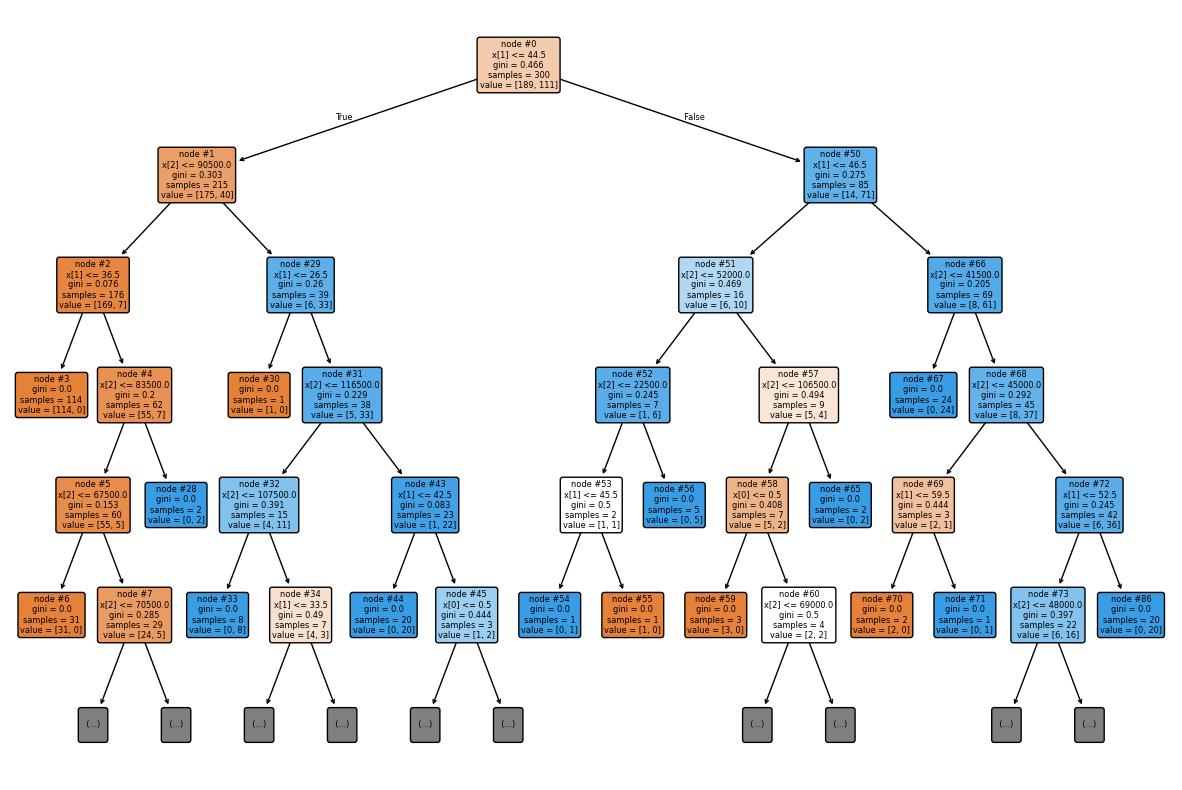

In [34]:
from sklearn import tree
plt.figure(figsize=(15, 10))
tree.plot_tree(DTC,
               filled=True,
               max_depth=5,
               node_ids=True,
               rounded=True)

In [25]:
from sklearn.metrics import confusion_matrix
CM = confusion_matrix(y_test, y_pred)
CM

array([[63,  5],
       [ 3, 29]])

In [31]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy: ', acc)

Accuracy:  0.92


## Conclusion
Decision Trees use Entropy or Gini to reduce impurity and build interpretable models.  
Proper hyperparameter tuning prevents overfitting and underfitting.